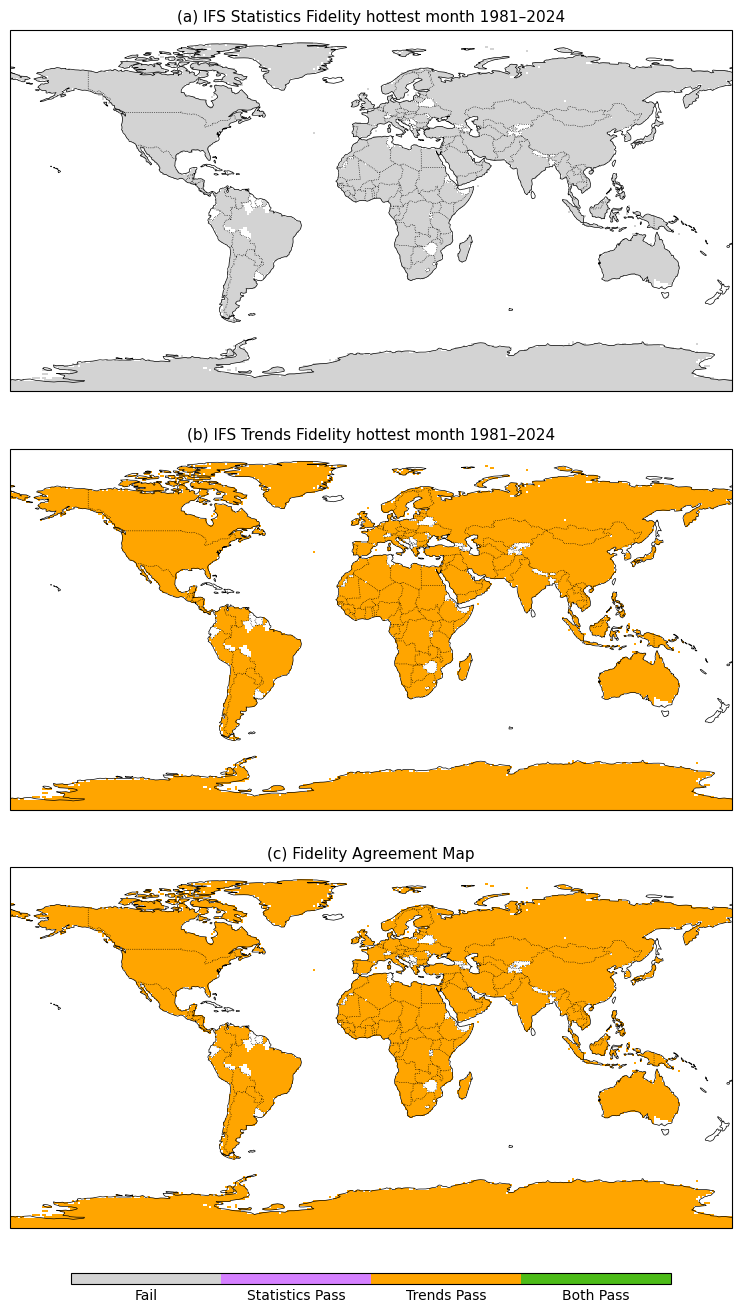

In [5]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from scipy.signal import detrend
from scipy.stats import linregress

def load_and_test(era5_file, proxy_file, region_grid_ds):
    era5_dataset = xr.open_dataset(era5_file)
    proxy_dataset = xr.open_dataset(proxy_file)
    regions = era5_dataset.region_id.values

    era5_means = np.zeros(len(regions))
    era5_stds = np.zeros(len(regions))
    era5_skews = np.zeros(len(regions))
    era5_kurts = np.zeros(len(regions))

    proxy_means = proxy_dataset.means.values
    proxy_stds = proxy_dataset.stds.values
    proxy_skews = proxy_dataset.skews.values
    proxy_kurts = proxy_dataset.kurts.values

    pass_test = np.zeros(len(regions))

    for i, region in enumerate(regions):
        era5_data = era5_dataset.sel(region_id=region, year=slice(1981, 2024)).t2m_hottest
        era5_data_detrended = detrend(era5_data, axis=0)

        era5_means[i] = era5_data_detrended.mean()
        era5_stds[i] = era5_data_detrended.std()
        era5_skews[i] = stats.skew(era5_data_detrended)
        era5_kurts[i] = stats.kurtosis(era5_data_detrended)

        mean_5th, mean_95th = np.percentile(proxy_means[:, i], [5, 95])
        std_5th, std_95th = np.percentile(proxy_stds[:, i], [5, 95])
        skew_5th, skew_95th = np.percentile(proxy_skews[:, i], [5, 95])
        kurt_5th, kurt_95th = np.percentile(proxy_kurts[:, i], [5, 95])

        mean_pass = mean_5th <= era5_means[i] <= mean_95th
        std_pass = std_5th <= era5_stds[i] <= std_95th
        skew_pass = skew_5th <= era5_skews[i] <= skew_95th
        kurt_pass = kurt_5th <= era5_kurts[i] <= kurt_95th

        if std_pass and skew_pass and kurt_pass:
            pass_test[i] = 1
        #if std_pass and skew_pass and kurt_pass and mean_pass:
            #pass_test[i] = 1

    region_grid = region_grid_ds.region_id
    pass_test_grid = xr.full_like(region_grid, np.nan, dtype=float)

    for i, rid in enumerate(regions):
        pass_test_grid = pass_test_grid.where(region_grid != rid, pass_test[i])

    return pass_test_grid

def load_and_test_trend(era5_file, proxy_file, region_grid_file):
    era5_dataset = xr.open_dataset(era5_file)
    region_grid_ds = xr.open_dataset(region_grid_file)
    proxy_dataset = xr.open_dataset(proxy_file)

    regions = era5_dataset.region_id.values
    years = era5_dataset.sel(year=slice(1981, 2024)).year

    era5_data_raw = era5_dataset.sel(year=slice(1981, 2024)).t2m_hottest

    def calc_slope_intercept(y, x):
        mask = np.isfinite(y)
        if mask.sum() < 2:
            return np.nan, np.nan
        slope, intercept, _, _, _ = linregress(x[mask], y[mask])
        return slope, intercept

    slope, intercept = xr.apply_ufunc(
        calc_slope_intercept,
        era5_data_raw,
        years,
        input_core_dims=[['year'], ['year']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[era5_data_raw.dtype, era5_data_raw.dtype]
    )

    proxy_slope = proxy_dataset.slope
    proxy_intercept = proxy_dataset.intercept

    slope_p05 = proxy_slope.quantile(0.05, dim='sample')
    slope_p95 = proxy_slope.quantile(0.95, dim='sample')
    intercept_p05 = proxy_intercept.quantile(0.05, dim='sample')
    intercept_p95 = proxy_intercept.quantile(0.95, dim='sample')

    era5_region_ids = era5_dataset.region_id.values
    proxy_region_ids = proxy_dataset.region_id.values

    region_id_to_index = {rid: i for i, rid in enumerate(proxy_region_ids)}
    proxy_idx = [region_id_to_index[r] for r in era5_region_ids]

    slope_05 = slope_p05.isel(region_id=proxy_idx).values
    slope_95 = slope_p95.isel(region_id=proxy_idx).values
    intercept_05 = intercept_p05.isel(region_id=proxy_idx).values
    intercept_95 = intercept_p95.isel(region_id=proxy_idx).values

    era5_slope = slope.values
    era5_intercept = intercept.values

    pass_slope = (era5_slope >= slope_05) & (era5_slope <= slope_95)
    pass_intercept = (era5_intercept >= intercept_05) & (era5_intercept <= intercept_95)

    category = np.where(pass_slope & pass_intercept, 1,
                        np.where(pass_slope, 0.5, 0))

    region_mask = region_grid_ds['region_id']
    region_plot = np.full(region_mask.shape, np.nan)
    for i, region_id in enumerate(era5_region_ids):
        region_plot[region_mask.values == region_id] = category[i]

    return region_plot

# 加载 region_grid
region_grid_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

# 加载 IFS 和 DP3 检验结果
grid_ifs = load_and_test(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc",
    "IFS_proxy_statistics_hottest_regional_1981_2024_corrected_segmented.nc",
    region_grid_ds
)

grid_dp3 = load_and_test_trend(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc",
    "IFS_proxy_trends_hottest_1981_2024_bias_corrected.nc",
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

# 构建比较图
grid_comparison = xr.full_like(grid_ifs, np.nan, dtype=float)
for i in range(grid_ifs.shape[0]):
    for j in range(grid_ifs.shape[1]):
        val1 = grid_ifs[i, j].item()
        val2 = grid_dp3[i, j].item()
        if np.isnan(val1) or np.isnan(val2):
            continue
        if val1 == 1 and val2 == 1:
            grid_comparison[i, j] = 3
        elif val1 == 1:
            grid_comparison[i, j] = 1
        elif val2 == 1:
            grid_comparison[i, j] = 2
        else:
            grid_comparison[i, j] = 0

# colormaps and normalization
cmap_ifs = mcolors.ListedColormap(["#D3D3D3", "#d580ff"])
cmap_dp3 = mcolors.ListedColormap(["#D3D3D3", "#ffa500"])
cmap_comparison = mcolors.ListedColormap(["#D3D3D3", "#d580ff", "#ffa500", "#4cbb17"])

norm_ifs = mcolors.BoundaryNorm([-0.1, 0.75, 1.1], cmap_ifs.N)
norm_dp3 = mcolors.BoundaryNorm([-0.1, 0.75, 1.1], cmap_dp3.N)
norm_comp = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_comparison.N)

# 准备绘图
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 14),
                        subplot_kw={'projection': ccrs.PlateCarree()})

titles = ["(a) IFS Statistics Fidelity hottest month 1981–2024",
          "(b) IFS Trends Fidelity hottest month 1981–2024",
          "(c) Fidelity Agreement Map"]

datasets = [grid_ifs, grid_dp3, grid_comparison]
cmaps = [cmap_ifs, cmap_dp3, cmap_comparison]
norms = [norm_ifs, norm_dp3, norm_comp]

for ax, data, title, cmap, norm in zip(axs, datasets, titles, cmaps, norms):
    ax.set_title(title, fontsize=11)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    im = ax.pcolormesh(region_grid_ds.longitude, region_grid_ds.latitude, data,
                       shading="auto", cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

fig.tight_layout(pad=3.0)
fig.subplots_adjust(bottom=0.1)
cbar_ax = fig.add_axes([0.2, 0.06, 0.6, 0.008])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=[0, 1, 2, 3])
cbar.ax.set_xticklabels(["Fail", "Statistics Pass", "Trends Pass", "Both Pass"])
cbar.ax.tick_params(which='both', length=0)

plt.savefig("IFS_Fidelity_Comparison_hottestmonth_1981_2024_Berkeley.png", dpi=300)
plt.show()


In [4]:
# === 统计绿色区域（fidelity_score = 3）对应的 region_id ===
region_id_grid = region_grid_ds.region_id

# 找出绿色区域（值为 3）的格点
green_mask = grid_comparison == 3

# 提取对应的 region_id
green_region_ids = np.unique(region_id_grid.where(green_mask).values)
green_region_ids = green_region_ids[np.isfinite(green_region_ids)].astype(int)

# 输出统计结果
print("=== Fidelity = 3 (绿色区域) ===")
print(f"区域数量: {len(green_region_ids)}")
print("区域ID列表:")
print(green_region_ids)


=== Fidelity = 3 (绿色区域) ===
区域数量: 0
区域ID列表:
[]


In [30]:
# === 统计绿色区域（fidelity_score = 3 且经度在 60E–180E）对应的 region_id ===
region_id_grid = region_grid_ds['region_id']
lon = region_id_grid['longitude']

# 找出绿色区域（值为 3）的格点
green_mask = (grid_comparison == 3)

# 添加经度筛选条件
lon_mask = (lon >= 60) & (lon <= 180)

# 需要让 lon_mask 维度与数据一致 (broadcast)
_, lon2d = xr.broadcast(region_id_grid['latitude'], lon)
lon_mask_2d = (lon2d >= 60) & (lon2d <= 180)

# 结合两个掩膜：绿色区域 + 经度筛选
combined_mask = green_mask & lon_mask_2d

# 提取对应的 region_id
green_region_ids = np.unique(region_id_grid.where(combined_mask).values)
green_region_ids = green_region_ids[np.isfinite(green_region_ids)].astype(int)

# 输出结果
print("=== Fidelity = 3 且经度在 60E–180E 区域 ===")
print(f"区域数量: {len(green_region_ids)}")
print("区域ID列表:")
print(green_region_ids)
print(" ")
# === 统计 fidelity_score = 3 且经度在 -10~60、纬度在 30N 以北的 region_id ===
region_id_grid = region_grid_ds['region_id']
lat = region_id_grid['latitude']
lon = region_id_grid['longitude']

# 找出 fidelity_score = 3 的格点
green_mask = (grid_comparison == 3)

# 生成二维经纬度网格（与数据维度对应）
lat2d, lon2d = xr.broadcast(lat, lon)

# 构造经纬度筛选掩膜
region_mask = (lon2d >= -10) & (lon2d <=58) & (lat2d >= 35)

# 合并掩膜（fidelity=3 且满足经纬度条件）
combined_mask = green_mask & region_mask

# 提取 region_id
selected_region_ids = np.unique(region_id_grid.where(combined_mask).values)
selected_region_ids = selected_region_ids[np.isfinite(selected_region_ids)].astype(int)

# 输出结果
print("=== Fidelity = 3 且经度在 -10~60E，纬度 ≥30N ===")
print(f"区域数量: {len(selected_region_ids)}")
print("区域ID列表:")
print(selected_region_ids)
print(" ")

# === 统计绿色区域（fidelity_score = 3 且经度在 -180 ~ -10）对应的 region_id ===
region_id_grid = region_grid_ds['region_id']
lon = region_id_grid['longitude']

# 找出绿色区域（值为 3）的格点
green_mask = (grid_comparison == 3)

# 需要让经度掩膜维度与数据一致 (broadcast)
_, lon2d = xr.broadcast(region_id_grid['latitude'], lon)

# 构造经度筛选掩膜
lon_mask_2d = (lon2d >= -180) & (lon2d <= -10)

# 结合两个掩膜：绿色区域 + 经度筛选
combined_mask = green_mask & lon_mask_2d

# 提取对应的 region_id
green_region_ids = np.unique(region_id_grid.where(combined_mask).values)
green_region_ids = green_region_ids[np.isfinite(green_region_ids)].astype(int)

# 输出结果
print("=== Fidelity = 3 且经度在 -180 ~ -10 区域 ===")
print(f"区域数量: {len(green_region_ids)}")
print("区域ID列表:")
print(green_region_ids)
print(" ")
# === 统计绿色区域（fidelity_score = 3 且经度在 -20~55，纬度在 -60~30）对应的 region_id ===
region_id_grid = region_grid_ds['region_id']
lat = region_id_grid['latitude']
lon = region_id_grid['longitude']

# 找出绿色区域（值为 3）的格点
green_mask = (grid_comparison == 3)

# 生成二维经纬度网格（与数据维度对应）
lat2d, lon2d = xr.broadcast(lat, lon)

# 构造经纬度筛选掩膜
region_mask = (lon2d >= -20) & (lon2d <= 55) & (lat2d >= -60) & (lat2d <= 30)

# 合并掩膜（fidelity=3 且满足经纬度条件）
combined_mask = green_mask & region_mask

# 提取 region_id
selected_region_ids = np.unique(region_id_grid.where(combined_mask).values)
selected_region_ids = selected_region_ids[np.isfinite(selected_region_ids)].astype(int)

# 输出结果
print("=== Fidelity = 3 且经度在 -20~55，纬度在 -60~30 区域 ===")
print(f"区域数量: {len(selected_region_ids)}")
print("区域ID列表:")
print(selected_region_ids)



=== Fidelity = 3 且经度在 60E–180E 区域 ===
区域数量: 16
区域ID列表:
[102 108 110 115 116 130 136 144 145 149 150 155 207 208 229 230]
 
=== Fidelity = 3 且经度在 -10~60E，纬度 ≥30N ===
区域数量: 14
区域ID列表:
[102 104 105 106 130 134 136 198 199 200 201 203 204 234]
 
=== Fidelity = 3 且经度在 -180 ~ -10 区域 ===
区域数量: 19
区域ID列表:
[  1   5   9  10  13  19  21  22  24  37 170 173 176 181 194 195 203 218
 224]
 
=== Fidelity = 3 且经度在 -20~55，纬度在 -60~30 区域 ===
区域数量: 12
区域ID列表:
[ 57  61  71  79  80  86  88  94  95 225 227 228]


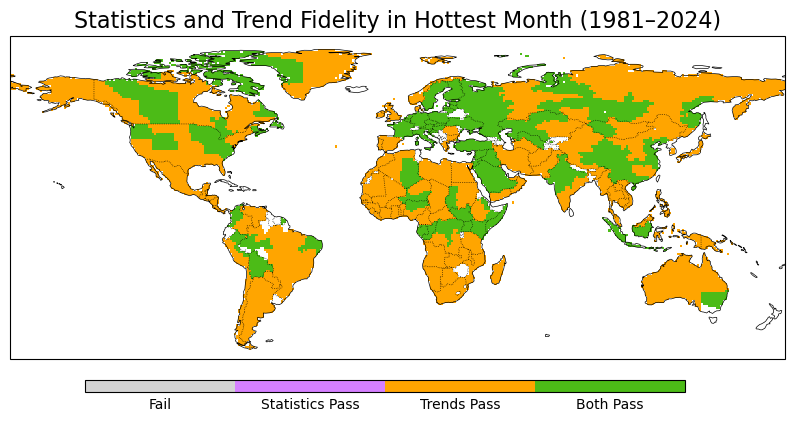

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# === 读取 region_grid 和 grid_comparison ===
region_grid_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

# 示例：grid_comparison 是你前面代码中计算得出的结果
# 如果 grid_comparison 是 np.ndarray，则转换为 xarray.DataArray：
grid_comparison = xr.DataArray(
    grid_comparison,
    coords={'latitude': region_grid_ds.latitude, 'longitude': region_grid_ds.longitude},
    dims=('latitude', 'longitude')
)

# === 配色与分类 ===
cmap_comparison = mcolors.ListedColormap(["#D3D3D3", "#d580ff", "#ffa500", "#4cbb17"])  # 灰/蓝/橙/绿
norm_comp = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_comparison.N)

# === 绘图 ===
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_title("Statistics and Trend Fidelity in Hottest Month (1981–2024)", fontsize=16)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# 绘制数据
im = ax.pcolormesh(
    grid_comparison.longitude,
    grid_comparison.latitude,
    grid_comparison,
    shading='auto',
    cmap=cmap_comparison,
    norm=norm_comp,
    transform=ccrs.PlateCarree()
)

# === 单独用 fig.add_axes() 设置 colorbar 位置 ===
cbar_ax = fig.add_axes([0.2, 0.17, 0.6, 0.02])
# 参数解释：[left, bottom, width, height]，相对 figure 的百分比位置

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_xticklabels(["Fail", "Statistics Pass", "Trends Pass", "Both Pass"])
cbar.ax.tick_params(which='both', length=0)
#cbar.set_label("Fidelity Categories")

# 保存图片
plt.savefig("Fidelity_1981_2024.png", dpi=300, bbox_inches='tight')
plt.show()


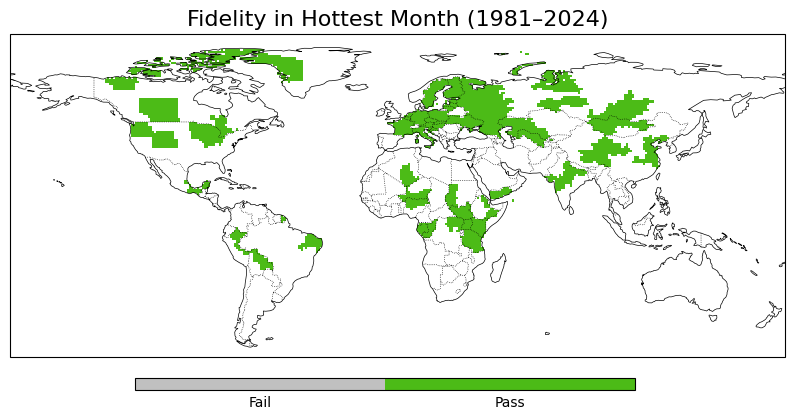

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# === 读取 region_grid 和 grid_comparison ===
region_grid_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

grid_comparison = xr.DataArray(
    grid_comparison,
    coords={'latitude': region_grid_ds.latitude,
            'longitude': region_grid_ds.longitude},
    dims=('latitude', 'longitude')
)

# -------------------------------------------------
# ✅ 关键修改 ① ：只保留 Trends Pass(2) 和 Pass Both(3)
# -------------------------------------------------
grid_plot = grid_comparison.where(grid_comparison.isin([2, 3]))

# -------------------------------------------------
# ✅ 关键修改 ② ：二分类 colormap
# -------------------------------------------------
cmap_comparison = mcolors.ListedColormap([
    "silver",   # Trends Pass
    "#4cbb17"    # Pass (Both)
])

# -------------------------------------------------
# ✅ 关键修改 ③ ：对应 norm（2 段）
# -------------------------------------------------
norm_comp = mcolors.BoundaryNorm([1.5, 2.5, 3.5],
                                 cmap_comparison.N)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax.set_title("Fidelity in Hottest Month (1981–2024)",
             fontsize=16)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    grid_plot.longitude,
    grid_plot.latitude,
    grid_plot,
    shading='auto',
    cmap=cmap_comparison,
    norm=norm_comp,
    transform=ccrs.PlateCarree()
)

# -------------------------------------------------
# colorbar（2 类）
# -------------------------------------------------
cbar_ax = fig.add_axes([0.25, 0.17, 0.5, 0.02])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=[2, 3]
)

cbar.ax.set_xticklabels([
    "Fail",
    "Pass"
])

cbar.ax.tick_params(which='both', length=0)

# -------------------------------------------------
# Save
# -------------------------------------------------
plt.savefig(
    "Fidelity_1981_2024_trend_and_pass_only.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


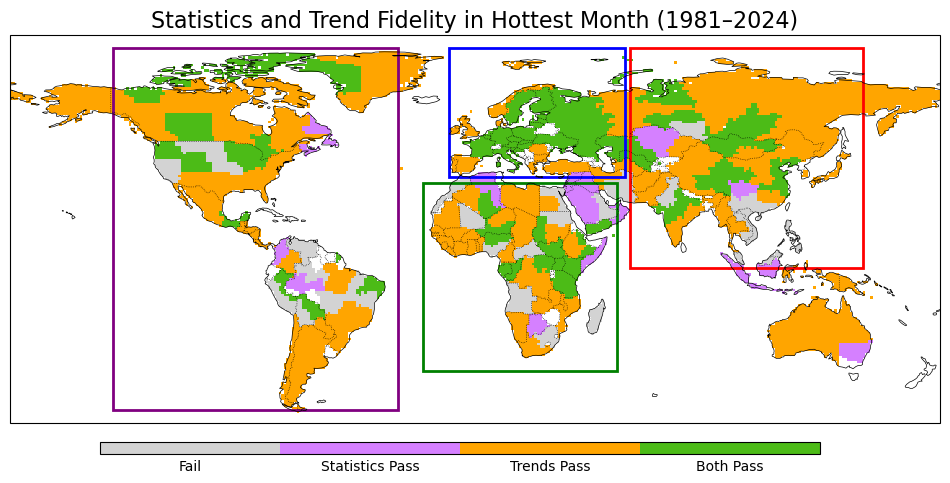

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# === 读取 region_grid 和 grid_comparison ===
region_grid_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

# 示例：grid_comparison 是你前面代码中计算得出的结果
# 如果 grid_comparison 是 np.ndarray，则转换为 xarray.DataArray：
grid_comparison = xr.DataArray(
    grid_comparison,
    coords={'latitude': region_grid_ds.latitude, 'longitude': region_grid_ds.longitude},
    dims=('latitude', 'longitude')
)

# === 配色与分类 ===
cmap_comparison = mcolors.ListedColormap(["#D3D3D3", "#d580ff", "#ffa500", "#4cbb17"])  # 灰/蓝/橙/绿
norm_comp = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_comparison.N)

# === 绘图 ===
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_title("Statistics and Trend Fidelity in Hottest Month (1981–2024)", fontsize=16)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# 绘制数据
im = ax.pcolormesh(
    grid_comparison.longitude,
    grid_comparison.latitude,
    grid_comparison,
    shading='auto',
    cmap=cmap_comparison,
    norm=norm_comp,
    transform=ccrs.PlateCarree()
)

# === 绘制矩形区域 ===
regions_rects = [
    {"lon_min": 60, "lon_max": 150, "lat_min": 0, "lat_max": 85, "color": "red"},
    {"lon_min": -10, "lon_max": 58, "lat_min": 35, "lat_max": 85, "color": "blue"},
    {"lon_min": -140, "lon_max": -30, "lat_min": -55, "lat_max": 85, "color": "purple"},
    {"lon_min": -20, "lon_max": 55, "lat_min": -40, "lat_max": 33, "color": "green"}
]

for r in regions_rects:
    width = r["lon_max"] - r["lon_min"]
    height = r["lat_max"] - r["lat_min"]
    rect = Rectangle(
        (r["lon_min"], r["lat_min"]),
        width,
        height,
        linewidth=2,
        edgecolor=r["color"],
        facecolor='none',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

# === 单独用 fig.add_axes() 设置 colorbar 位置 ===
cbar_ax = fig.add_axes([0.2, 0.12, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_xticklabels(["Fail", "Statistics Pass", "Trends Pass", "Both Pass"])
cbar.ax.tick_params(which='both', length=0)

# 保存图片
plt.savefig("Fidelity_1981_2024_with_regions.png", dpi=300, bbox_inches='tight')
plt.show()


In [4]:
# 假设 grid_comparison 是一个 xarray.DataArray，已经有经纬度坐标
grid_comparison.name = "fidelity_score"  # 设置变量名（保存到nc中使用）

# 保存为 NetCDF 文件
grid_comparison.to_netcdf("grid_comparison_fidelity_trend_corrected.nc")


In [5]:
ds = xr.open_dataset("grid_comparison_fidelity.nc")
print(ds)


<xarray.Dataset> Size: 523kB
Dimensions:         (latitude: 180, longitude: 360)
Coordinates:
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    fidelity_score  (latitude, longitude) float64 518kB ...


In [1]:
import xarray as xr
import numpy as np

# === 读取数据 ===
ds = xr.open_dataset("grid_comparison_fidelity.nc")

# 取出 fidelity_score 数据
fidelity = ds["fidelity_score"]

# === 统计各个取值的格点数量 ===
counts = {}
for val in [3, 2, 1, 0]:
    counts[val] = np.sum(fidelity.values == val)

# === 打印结果 ===
for val, num in counts.items():
    print(f"fidelity_score = {val}: {num} grid points")

# 可选：打印总格点数核对
total = np.prod(fidelity.shape)
print(f"Total grid points: {total}")


fidelity_score = 3: 4981 grid points
fidelity_score = 2: 11595 grid points
fidelity_score = 1: 1328 grid points
fidelity_score = 0: 3070 grid points
Total grid points: 64800


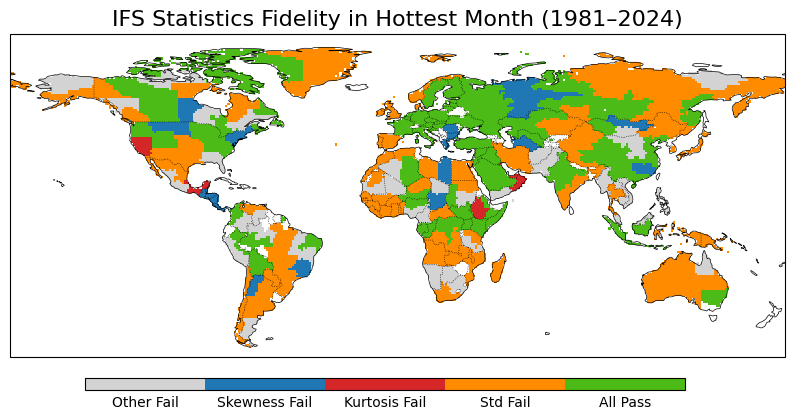

In [5]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from scipy.signal import detrend

def load_and_test_statistics(era5_file, proxy_file, region_grid_ds):
    era5_dataset = xr.open_dataset(era5_file)
    proxy_dataset = xr.open_dataset(proxy_file)
    regions = era5_dataset.region_id.values

    era5_stds = np.zeros(len(regions))
    era5_skews = np.zeros(len(regions))
    era5_kurts = np.zeros(len(regions))

    proxy_stds = proxy_dataset.stds.values
    proxy_skews = proxy_dataset.skews.values
    proxy_kurts = proxy_dataset.kurts.values

    # 分类码：
    # 0 = 多重失败或其他
    # 1 = skewness fail
    # 2 = kurtosis fail
    # 3 = std fail
    # 4 = all pass
    category = np.zeros(len(regions))

    for i, region in enumerate(regions):
        era5_data = era5_dataset.sel(region_id=region, year=slice(1981, 2024)).t2m_hottest
        era5_data_detrended = detrend(era5_data, axis=0)

        era5_stds[i] = era5_data_detrended.std()
        era5_skews[i] = stats.skew(era5_data_detrended)
        era5_kurts[i] = stats.kurtosis(era5_data_detrended)

        std_5th, std_95th = np.percentile(proxy_stds[:, i], [5, 95])
        skew_5th, skew_95th = np.percentile(proxy_skews[:, i], [5, 95])
        kurt_5th, kurt_95th = np.percentile(proxy_kurts[:, i], [5, 95])

        std_pass = std_5th <= era5_stds[i] <= std_95th
        skew_pass = skew_5th <= era5_skews[i] <= skew_95th
        kurt_pass = kurt_5th <= era5_kurts[i] <= kurt_95th

        # 分类逻辑
        if std_pass and skew_pass and kurt_pass:
            category[i] = 4  # 全部通过
        elif not skew_pass and std_pass and kurt_pass:
            category[i] = 1  # 仅 skewness 失败
        elif not kurt_pass and std_pass and skew_pass:
            category[i] = 2  # 仅 kurtosis 失败
        elif not std_pass and skew_pass and kurt_pass:
            category[i] = 3  # 仅 std 失败
        else:
            category[i] = 0  # 多重失败或其他

    region_grid = region_grid_ds.region_id
    category_grid = xr.full_like(region_grid, np.nan, dtype=float)

    for i, rid in enumerate(regions):
        category_grid = category_grid.where(region_grid != rid, category[i])

    return category_grid

# === 执行检验并绘图 ===
region_grid_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

grid_category = load_and_test_statistics(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc",
    "IFS_proxy_statistics_hottest_regional_1981_2024_land_bias_corrected.nc",
    region_grid_ds
)

# 颜色映射
cmap = mcolors.ListedColormap([
    "#D3D3D3",  # 0: 多重失败或其他
    "#1f77b4",  # 1: skewness fail (蓝)
    "#d62728",  # 2: kurtosis fail (红)
    "#ff8c00",  # 3: std fail (橙)
    "#4cbb17"   # 4: all pass (绿)
])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

# 绘图
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_title("IFS Statistics Fidelity in Hottest Month (1981–2024)", fontsize=16)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

im = ax.pcolormesh(region_grid_ds.longitude, region_grid_ds.latitude, grid_category,
                   shading="auto", cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar_ax = fig.add_axes([0.2, 0.17, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                    ticks=[0, 1, 2, 3, 4])
cbar.ax.set_xticklabels([
    "Other Fail", "Skewness Fail", "Kurtosis Fail", "Std Fail", "All Pass"
])
cbar.ax.tick_params(which='both', length=0)

plt.savefig("IFS_Statistics_Fidelity_DetailMap.png", dpi=300, bbox_inches="tight")
plt.show()
